In [1]:
import pandas as pd
import numpy as np


In [2]:
df=pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X=df.drop("PE",axis=1)
y=df["PE"]

In [6]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [8]:
df.shape

(9568, 5)

In [9]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [10]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

In [11]:
import torch
import torch.nn as nn

X_train_tensor=torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

X_test_tensor=torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [12]:
from torch.utils.data import TensorDataset,DataLoader

train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)

In [13]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

In [14]:
train_loader

# ANN

In [15]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()
        self.model=nn.Sequential(
            #1st hidden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            #2nd
            nn.Linear(6,6),
            nn.ReLU(),

            #output
            nn.Linear(6,1),
        )
    def forward(self,x):
        return self.model(x)

In [16]:
import torch.optim as optim

ann_model=ANN()
#loss,optimizer
crietrion=nn.MSELoss()
optimizer=optim.Adam(ann_model.parameters())

In [17]:
train_losses=[]
val_losses=[]

best_val_loss=float("inf")

epochs=100
for epoch in range(epochs):
    ann_model.train()
    running_loss=0.0  # tot training loss for 1 epoch

    for xb,yb in train_loader:
        optimizer.zero_grad()
        outputs=ann_model(xb)
        loss=crietrion(outputs,yb)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()
    epoch_train_loss=running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)

    #eval
    ann_model.eval()
    running_val_loss=0.0

    with torch.no_grad():
        for xb,yb in test_loader:
            outputs=ann_model(xb)
            loss=crietrion(outputs,yb)
            running_val_loss+=loss.item()
    epoch_val_loss=running_val_loss/len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs}==> train loss = {epoch_train_loss} & val loss={epoch_val_loss}")

    if epoch_val_loss<best_val_loss:
        best_val_loss=epoch_val_loss
        torch.save(ann_model.state_dict(),"best_model.pt")

epoch 1/100==> train loss = 205875.98346354166 & val loss=203272.44609375
epoch 2/100==> train loss = 194001.44303385416 & val loss=179669.47838541667
epoch 3/100==> train loss = 157139.31197916667 & val loss=133675.85377604168
epoch 4/100==> train loss = 113331.8085123698 & val loss=98689.94231770834
epoch 5/100==> train loss = 88398.83818359375 & val loss=80360.06451822916
epoch 6/100==> train loss = 70099.16498209635 & val loss=60551.540690104164
epoch 7/100==> train loss = 47565.31456705729 & val loss=36043.284505208336
epoch 8/100==> train loss = 24255.767224121093 & val loss=15430.656876627605
epoch 9/100==> train loss = 9486.788165283204 & val loss=5842.755013020834
epoch 10/100==> train loss = 4025.4289779663086 & val loss=2915.92465616862
epoch 11/100==> train loss = 2283.817198308309 & val loss=1791.4064005533853
epoch 12/100==> train loss = 1470.3710934956869 & val loss=1173.5479100545247
epoch 13/100==> train loss = 982.1573909759521 & val loss=793.0930862426758
epoch 14/10

In [18]:
best_val_loss

18.828439887364706

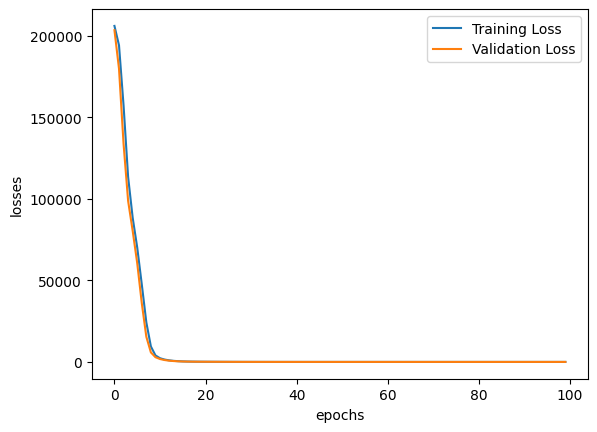

In [19]:
import matplotlib.pyplot as plt

loss_df=pd.DataFrame({
    "Training Loss":train_losses,
    "Validation Loss":val_losses
})

plt.plot(loss_df["Training Loss"],label="Training Loss")
plt.plot(loss_df["Validation Loss"],label="Validation Loss")

plt.xlabel("epochs")
plt.ylabel("losses")
plt.legend()

In [20]:
ann_model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [21]:
ann_model.eval()
with torch.no_grad():
    train_preds=ann_model(X_train_tensor)
    test_preds=ann_model(X_test_tensor)

    train_mse_loss=crietrion(train_preds,y_train_tensor)
    test_mse_loss=crietrion(test_preds,y_test_tensor)
print("Training MSE: ",train_mse_loss.item())
print("Testing MSE: ",test_mse_loss.item())

Training MSE:  20.300365447998047
Testing MSE:  18.83124542236328


In [22]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
r2_score_ann=r2_score(y_test,test_preds)
mae_score_ann=mean_absolute_error(y_test,test_preds)
rmse_score_ann=np.sqrt(mean_squared_error(y_test,test_preds))
print("r2_score: ",r2_score_ann)
print("MAE score: ",mae_score_ann)
print("RMSE score: ",rmse_score_ann)

r2_score:  0.934189656357709
MAE score:  3.4399486354401367
RMSE score:  4.339498048374695


In [23]:
predicted_df=pd.DataFrame(test_preds.numpy(),columns=["Predicted Values"])
actual_df=pd.DataFrame(y_test.values,columns=["Actual Values"])

pd.concat([predicted_df,actual_df],axis=1)

,Predicted Values,Actual Values
0,434.884155,433.27
1,436.747040,438.16
2,462.033356,458.42
3,477.220673,480.82
4,435.364105,441.41
...,...,...
1909,451.413025,456.70
1910,431.335449,438.04
1911,467.696045,467.80
1912,430.779175,437.14


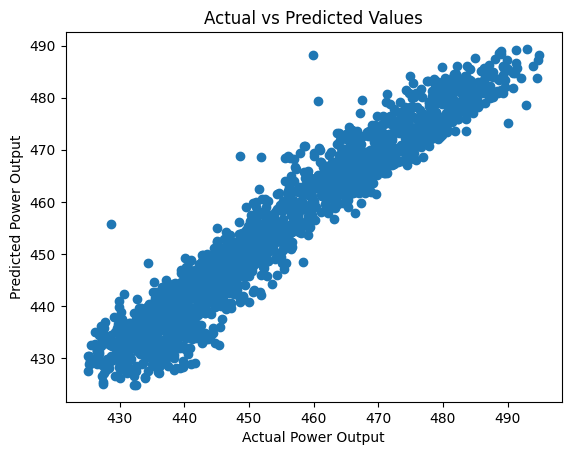

In [24]:
import matplotlib.pyplot as plt

plt.scatter(y_test, test_preds)
plt.xlabel("Actual Power Output")
plt.ylabel("Predicted Power Output")
plt.title("Actual vs Predicted Values")
plt.show()

# Other ML Models

In [25]:

df
X=df.drop("PE",axis=1)
y=df["PE"]

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [27]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [28]:
y

0       480.48
1       445.75
2       438.76
3       453.09
4       464.43
         ...  
9563    462.59
9564    432.90
9565    465.96
9566    450.93
9567    451.67
Name: PE, Length: 9568, dtype: float64

## Linear Regression

In [29]:
from sklearn.linear_model import LinearRegression

lr_model=LinearRegression()
lr_model.fit(X_train_scaled,y_train)
y_preds=lr_model.predict(X_test_scaled)
y_preds_train=lr_model.predict(X_train_scaled)
print("Testing R2_score: ",r2_score(y_test,y_preds))
print("Training R2_score: ",r2_score(y_train,y_preds_train))

Testing R2_score:  0.9314747936670361
Training R2_score:  0.9279951490925766


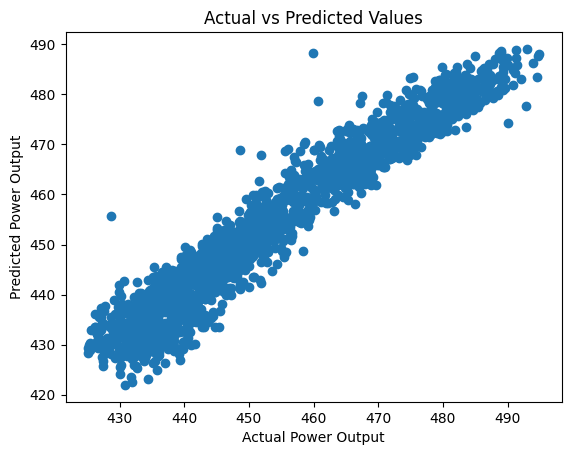

In [30]:


plt.scatter(y_test, y_preds)
plt.xlabel("Actual Power Output")
plt.ylabel("Predicted Power Output")
plt.title("Actual vs Predicted Values")
plt.show()

## Random Forest Regressor

         AT      V       AP     RH
5487  25.24  63.47  1011.30  66.21
3522  26.09  70.40  1007.41  85.37
6916  26.63  73.68  1015.15  85.13
7544  32.06  71.85  1007.90  56.44
7600  28.70  71.64  1007.11  69.85
(7654, 4)
Testing R2_score:  0.9520529572404044
Training R2_score:  0.9578583965433786


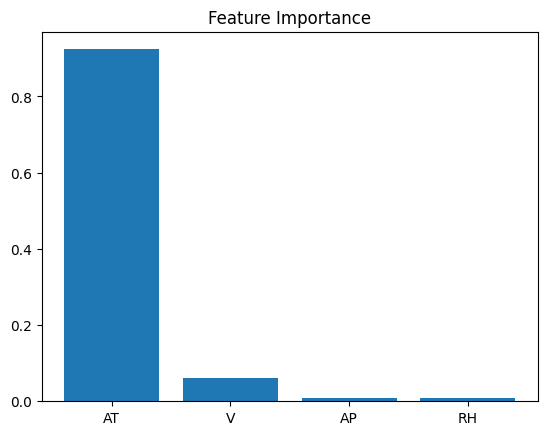

In [50]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor(n_estimators=100,max_depth=7,min_samples_split=6)
rf_model.fit(X_train,y_train)
y_preds=rf_model.predict(X_test)
y_preds_train=rf_model.predict(X_train)

print(X_train.head())
print(X_train.shape)
print("Testing R2_score: ",r2_score(y_test,y_preds))
print("Training R2_score: ",r2_score(y_train,y_preds_train))
importances = rf_model.feature_importances_

plt.bar(X.columns, importances)
plt.title("Feature Importance")
plt.show()

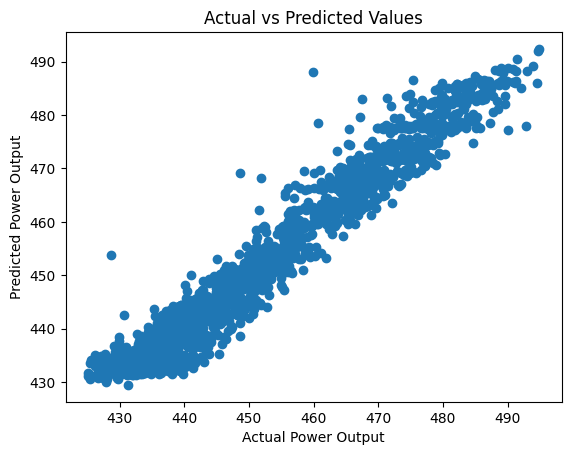

In [32]:


plt.scatter(y_test, y_preds)
plt.xlabel("Actual Power Output")
plt.ylabel("Predicted Power Output")
plt.title("Actual vs Predicted Values")
plt.show()

## Gradient Boosting Regressor

Training R2 Score:  0.9526149149621398
Testing R2 Score:  0.9514453856425775


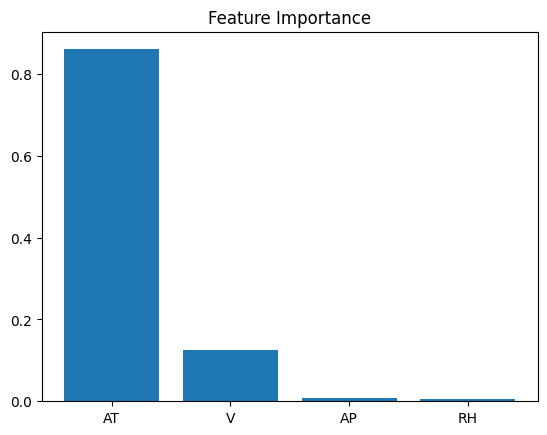

In [33]:
from sklearn.ensemble import GradientBoostingRegressor
gb_model=GradientBoostingRegressor()
gb_model.fit(X_train_scaled,y_train)
y_preds_train=gb_model.predict(X_train_scaled)
y_preds_test=gb_model.predict(X_test_scaled)
print("Training R2 Score: ",r2_score(y_train,y_preds_train))
print("Testing R2 Score: ",r2_score(y_test,y_preds_test))
importances = gb_model.feature_importances_

plt.bar(X.columns, importances)
plt.title("Feature Importance")
plt.show()

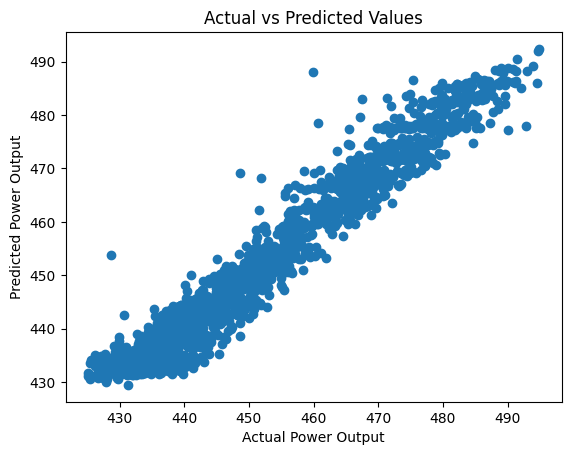

In [34]:


plt.scatter(y_test, y_preds)
plt.xlabel("Actual Power Output")
plt.ylabel("Predicted Power Output")
plt.title("Actual vs Predicted Values")
plt.show()

## XG Boost Regressor

         AT      V       AP     RH
5487  25.24  63.47  1011.30  66.21
3522  26.09  70.40  1007.41  85.37
6916  26.63  73.68  1015.15  85.13
7544  32.06  71.85  1007.90  56.44
7600  28.70  71.64  1007.11  69.85
(7654, 4)
Training R2 Score:  0.9799466846146611
Testing R2 Score:  0.9657424353180492


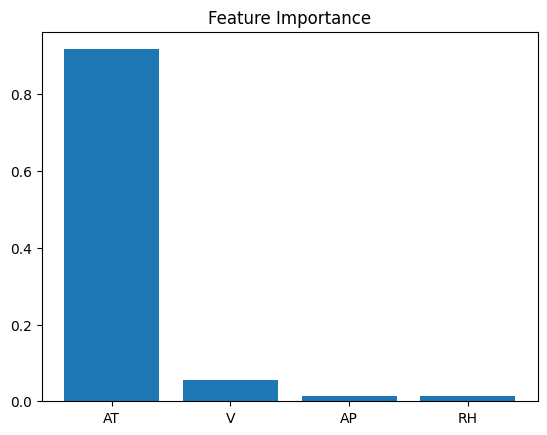

In [47]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
print(X_train.head())
print(X_train.shape)
xgb_model.fit(X_train,y_train)
y_preds_train=xgb_model.predict(X_train)
y_preds_test=xgb_model.predict(X_test)
print("Training R2 Score: ",r2_score(y_train,y_preds_train))
print("Testing R2 Score: ",r2_score(y_test,y_preds_test))
importances = xgb_model.feature_importances_

plt.bar(X.columns, importances)
plt.title("Feature Importance")
plt.show()

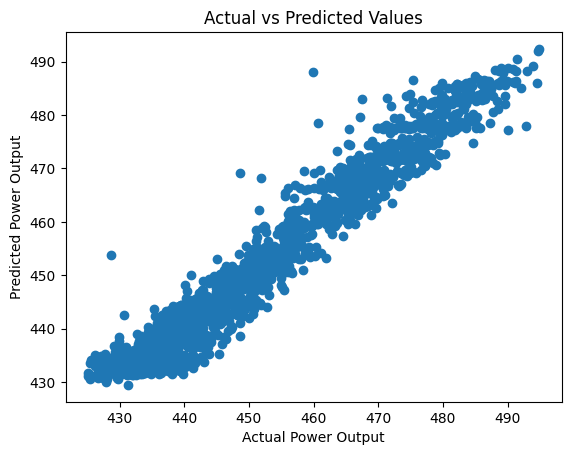

In [36]:


plt.scatter(y_test, y_preds)
plt.xlabel("Actual Power Output")
plt.ylabel("Predicted Power Output")
plt.title("Actual vs Predicted Values")
plt.show()

## Final Evaluation Metrics

In [37]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

models={
    "Linear Regression: ":lr_model,
    "Random Forest":rf_model,
    "Gradient Boosting":gb_model,
    "XG Boost":xgb_model,
    "ANN":ann_model
}

results=[]
for name,model in models.items():
    if name=="ANN":
        results.append([name,r2_score_ann,mae_score_ann,rmse_score_ann])
        continue
    y_pred=model.predict(X_test_scaled)
    r2=r2_score(y_test,y_pred)
    mae=mean_absolute_error(y_test,y_pred)
    rmse=np.sqrt(mean_squared_error(y_test,y_pred))
    results.append([name,r2,mae,rmse])

result_df=pd.DataFrame(results,columns=["Model","R2","MAE","RMSE"])
result_df.set_index("Model")

,R2,MAE,RMSE
Model,,,
Linear Regression:,0.931475,3.543448,4.428102
Random Forest,0.952244,2.822478,3.696643
Gradient Boosting,0.951445,2.869884,3.727414
XG Boost,0.965742,2.264589,3.130911
ANN,0.934190,3.439949,4.339498


In [52]:
import pickle

pickle.dump(xgb_model, open("power_model.pkl", "wb"))